# Part 1

In [1]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import scipy

## Task 1

In [2]:
P = np.array([[0.9915,0.005,0.0025,0,0.001],
                  [0,0.986,0.005,0.004,0.005],
                  [0,0,0.992,0.003,0.005],
                  [0,0,0,0.991,0.009],
                  [0,0,0,0,1]])

N,_ = P.shape

states = np.arange(1,N+1)

In [3]:
def discrMarkov(P):
    t = 0
    s = 1
    track = [(0,1)]
    while s != 5:
        probs = []
        for x in states:
            probs.append(P[s-1][x-1])

        s_next = int(np.random.choice(states, p=probs))
        s = s_next

        t += 1

        track.append((t, s))

    return t,track

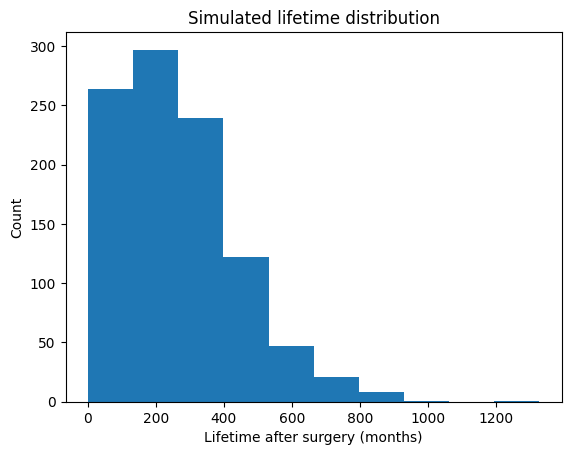

In [4]:
n_women = 1000

results = [discrMarkov(P) for i in range(n_women)]

lifetimes = np.array([t for t,track in results])
trackings = [track for t,track in results]

plt.hist(lifetimes)
plt.xlabel("Lifetime after surgery (months)")
plt.ylabel("Count")
plt.title("Simulated lifetime distribution")
plt.show()

In [5]:
n_locReap = sum(any(state in [2,4] for time, state in tracking) for tracking in trackings)

prop_locReap = n_locReap / n_women

print(prop_locReap)

0.701


## Task 2

In [6]:
p_0 = np.array([1,0,0,0,0])

In [7]:
def prob(t):
    return p_0 @ np.linalg.matrix_power(P,t)

In [8]:
t_test = 120
probs_expected = prob(t_test)
print(probs_expected)

[0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]


In [9]:
state_subset = np.array([next((state for time, state in tracking if time == t_test), 5) for tracking in trackings])

counts_observed = np.bincount(state_subset-1, minlength=N)

probs_observed = counts_observed / counts_observed.sum()

print(probs_observed)

[0.359 0.165 0.171 0.073 0.232]


In [10]:
counts_expected = counts_observed.sum() * probs_expected

#Manual:
T = 0
for i in range(N):
    T += (counts_observed[i] - counts_expected[i])**2 / counts_expected[i]

p = 1 - stats.chi2.cdf(T,N - 1)

print(p)

#Alternative
#statistic, p_value = stats.chisquare(counts_observed, counts_expected)

0.7652725875973052


## Task 3

In [57]:
P_s = np.array([[0.9915,0.005,0.0025,0],
                  [0,0.986,0.005,0.004],
                  [0,0,0.992,0.003],
                  [0,0,0,0.991]])

N_s,_ = P_s.shape

#Proability of dying is the probability of entering stage 5, which is:
p_15 = 0.001
p_25 = 0.005
p_35 = 0.005
p_45 = 0.009

p_s = np.array([p_15,p_25,p_35,p_45])

pi = np.array([1,0,0,0])

ones = np.array([1,1,1,1])

In [22]:
def P_T(t):
    return pi @ np.linalg.matrix_power(P_s,t) @ p_s

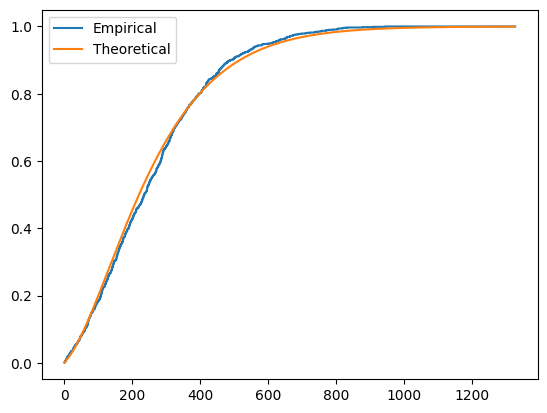

In [31]:
T = np.arange(0,max(lifetimes),1)
theory = np.array(np.cumsum([P_T(t) for t in T]))

lifetime_sorted = np.sort(lifetimes)
empiry = np.arange(1, n_women+1) / n_women

plt.step(lifetime_sorted,empiry, label="Empirical")
plt.plot(T, theory, label="Theoretical")
plt.legend()
plt.show()

## Task 5

In [32]:
def d(t,tracking):
    count = 0
    for track in tracking:
        for time,state in track:
            if state == 5 and time <= t:
                count += 1

    return count

In [ ]:
n_women = 200
n_reps = 10

control = []
fracs = []
for i in range(n_reps):
    results = [discrMarkov(P) for i in range(n_women)]
    lifetimes = np.array([t for t,track in results])
    
    control.append(float(np.mean(lifetimes)))
    fracs.append(float(np.sum(lifetimes <= 350)/n_women))

In [ ]:
I = np.eye(N_s)

mean_expectation = pi @ np.linalg.inv(I - P_s) @ ones

In [ ]:
mu_Z = mean_expectation

Z = np.array(control)
X = np.array(fracs)

c = - np.cov(X, Z, ddof=1)[0,1] / np.var(Z, ddof=1)

Y = X + c*(Z - mu_Z)

var_crude = np.var(X, ddof=1)
var_cv = np.var(Y, ddof=1)

print("Crude variance:", var_crude)
print("Control variate variance:", var_cv)

reduction = 100 * (1 - var_cv/var_crude)

print("Variance reduction (%):",reduction)


Crude variance: 0.0006655555555555568
Control variate variance: 0.00012098465014584128
Variance reduction (%): 81.82200582115911
